# Truth-Risk Intelligence: Detecting Low-Truth Political Claims with Text and Context

This is the curated final notebook for the CSCE 676 project deliverable.

## Motivation
Political misinformation spreads faster than manual fact-checking can respond. This project studies how data mining can triage likely low-truth claims earlier to support analysts, journalists, and fact-checkers.

## Dataset
We use the LIAR dataset (PolitiFact fact-checked political statements), including train/validation/test splits and metadata fields such as subject, speaker, state, party, and historical truthfulness counts.

## Research Questions
1. Can combining text embeddings with speaker-graph context improve low-truth detection?
2. Do improvements remain under speaker-disjoint evaluation (reduced memorization risk)?
3. Which modeling strategy offers the best practical performance for this task?

## Preprocessing
The pipeline standardizes key metadata fields, builds `is_low_truth` labels, generates text embeddings (TF-IDF, MiniLM, BERT), and builds speaker-subject graph embeddings. Outputs are stored in `data/interim` and `data/processed`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
proc = Path('data/processed')
interim = Path('data/interim')
proc.exists(), interim.exists()

(True, True)

## Exploratory Data Analysis
We inspect label balance and metadata composition to understand the prediction setting and class imbalance.

In [2]:
base = pd.read_parquet(proc / 'liar_base.parquet')
base[['split','label','is_low_truth']].head()

,split,label,is_low_truth
0,train,false,1
1,train,half-true,0
2,train,mostly-true,0
3,train,false,1
4,train,half-true,0


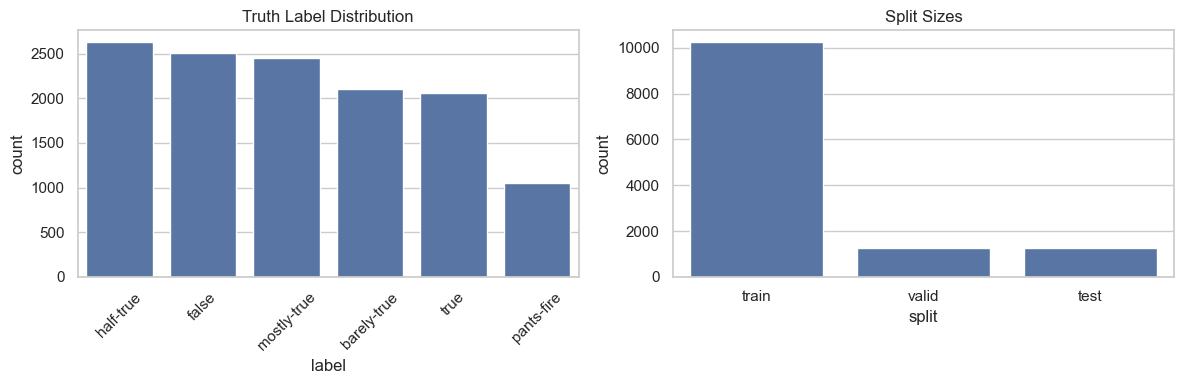

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.countplot(data=base, x='label', order=base['label'].value_counts().index, ax=ax[0])
ax[0].set_title('Truth Label Distribution')
ax[0].tick_params(axis='x', rotation=45)
sns.countplot(data=base, x='split', order=['train','valid','test'], ax=ax[1])
ax[1].set_title('Split Sizes')
plt.tight_layout()
plt.show()

## Modeling
We benchmark multiple embeddings and classifiers, then add advanced models (fine-tuned transformer, tuned tabular fusion, and ensemble threshold optimization).

In [4]:
bench_path = proc / 'embedding_classifier_model_comparison.csv'
if bench_path.exists():
    bench = pd.read_csv(bench_path)
    display(bench.sort_values(['setting','variant','f1'], ascending=[True,True,False]).head(12))
else:
    print('Missing benchmark table. Run scripts/10_embedding_benchmark.py')

,embedding,classifier,setting,variant,accuracy,precision,recall,f1,roc_auc
36,bert_base,linear_svm,fixed_split_train_test,text_only,0.630624,0.568218,0.640145,0.602041,0.675303
32,bert_base,logistic_regression,fixed_split_train_test,text_only,0.629045,0.566828,0.636528,0.599659,0.675285
0,tfidf,logistic_regression,fixed_split_train_test,text_only,0.615627,0.551724,0.636528,0.591100,0.652742
4,tfidf,linear_svm,fixed_split_train_test,text_only,0.612470,0.547988,0.640145,0.590492,0.653112
44,bert_base,gradient_boosting,fixed_split_train_test,text_only,0.599842,0.534954,0.636528,0.581338,0.653520
20,minilm,linear_svm,fixed_split_train_test,text_only,0.615627,0.554455,0.607595,0.579810,0.641728
16,minilm,logistic_regression,fixed_split_train_test,text_only,0.612470,0.551155,0.603978,0.576359,0.644050
28,minilm,gradient_boosting,fixed_split_train_test,text_only,0.599053,0.536116,0.603978,0.568027,0.640127
12,tfidf,gradient_boosting,fixed_split_train_test,text_only,0.581689,0.518699,0.576854,0.546233,0.627750
8,tfidf,random_forest,fixed_split_train_test,text_only,0.595896,0.550617,0.403255,0.465553,0.637607


## Evaluation
We evaluate with two settings: fixed split and speaker-disjoint split. This checks whether gains come from robust generalization rather than speaker memorization.

In [5]:
if bench_path.exists():
    piv = bench.pivot_table(index=['setting','embedding','classifier'], columns='variant', values='f1').reset_index()
    if {'text_only','text_plus_graph'}.issubset(piv.columns):
        piv['fusion_gain_f1'] = piv['text_plus_graph'] - piv['text_only']
        display(piv.sort_values('fusion_gain_f1', ascending=False).head(10))
        print('Average fusion gain by setting:')
        print(piv.groupby('setting')['fusion_gain_f1'].mean())

variant,setting,embedding,classifier,text_only,text_plus_graph,fusion_gain_f1
7,fixed_split_train_test,minilm,random_forest,0.371571,0.462085,0.090514
12,speaker_disjoint_split,bert_base,gradient_boosting,0.547730,0.576462,0.028733
3,fixed_split_train_test,bert_base,random_forest,0.426634,0.454874,0.028240
11,fixed_split_train_test,tfidf,random_forest,0.465553,0.491111,0.025558
19,speaker_disjoint_split,minilm,random_forest,0.358849,0.383285,0.024436
8,fixed_split_train_test,tfidf,gradient_boosting,0.546233,0.569921,0.023688
20,speaker_disjoint_split,tfidf,gradient_boosting,0.558414,0.580021,0.021606
22,speaker_disjoint_split,tfidf,logistic_regression,0.591012,0.606852,0.015840
15,speaker_disjoint_split,bert_base,random_forest,0.341704,0.356932,0.015229
16,speaker_disjoint_split,minilm,gradient_boosting,0.559520,0.574093,0.014574


Average fusion gain by setting:
setting
fixed_split_train_test    0.017659
speaker_disjoint_split    0.012906
Name: fusion_gain_f1, dtype: float64


## Results
The core finding is that combining text and context improves low-truth detection robustness. We also compare baseline benchmark models against transformer fine-tuning, tuned tabular fusion, and ensemble outputs.

In [6]:
rows = []
if bench_path.exists():
    top = bench.sort_values('f1', ascending=False).iloc[0]
    rows.append({'source':'embedding_classifier_benchmark', **top.to_dict()})

for p in proc.glob('transformer_finetune_metrics_*.json'):
    d = json.loads(p.read_text())
    for s in ['fixed_split_train_test','speaker_disjoint_split']:
        if s in d:
            rows.append({'source':p.stem, 'setting':s, **d[s]})

for p in proc.glob('tuned_tabular_fusion_metrics_*.json'):
    d = json.loads(p.read_text())
    for s in ['fixed_split_train_test','speaker_disjoint_split']:
        if s in d:
            rows.append({'source':p.stem, 'setting':s, **d[s]})

ens = proc / 'ensemble_threshold_metrics.json'
if ens.exists():
    d = json.loads(ens.read_text())
    for s,v in d.items():
        rows.append({'source':'ensemble_threshold', 'setting':s, **v.get('eval_metrics', {})})

pd.DataFrame(rows)

,source,embedding,classifier,setting,variant,accuracy,precision,recall,f1,roc_auc
0,embedding_classifier_benchmark,bert_base,logistic_regression,speaker_disjoint_split,text_plus_graph,0.630006,0.600891,0.637407,0.618611,0.669705
1,transformer_finetune_metrics_bert-base-uncased,NaN,NaN,fixed_split_train_test,NaN,0.642463,0.602459,0.531646,0.564841,0.688777
2,transformer_finetune_metrics_bert-base-uncased,NaN,NaN,speaker_disjoint_split,NaN,0.641132,0.660000,0.490209,0.562573,0.684365
3,tuned_tabular_fusion_metrics_text_embeddings_s...,NaN,NaN,fixed_split_train_test,NaN,0.732439,0.722917,0.627486,0.671830,0.806021
4,tuned_tabular_fusion_metrics_text_embeddings_s...,NaN,NaN,speaker_disjoint_split,NaN,0.703433,0.714734,0.615800,0.661589,0.794068
5,ensemble_threshold,NaN,NaN,fixed_split_train_test,NaN,0.616379,0.553633,0.765550,0.642570,0.682841
6,ensemble_threshold,NaN,NaN,speaker_disjoint_split,NaN,0.561162,0.482873,0.804788,0.603591,0.677647


## Limitations
- LIAR is relatively small and domain-specific.
- Labeling reflects fact-checking workflow and may contain selection effects.
- Some advanced models require substantial compute and tuning.
- Results may shift with alternative splits or external validation datasets.

## Conclusion
This project demonstrates that combining text embeddings with speaker-graph context improves low-truth claim detection and remains effective under stricter speaker-disjoint evaluation. The final pipeline provides a practical, reproducible framework for misinformation triage using data mining techniques.